# Import Library & Set Globals

In [1]:
# base
import os
import sys
import warnings
import logging
import pickle

# data manipulation
import pickle
import pandas as pd
import itables
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# single cell
import scanpy as sc
import decoupler as dc
import gseapy as gp

itables.init_notebook_mode(connected=True)  # Use connected=False for offline use
warnings.simplefilter("ignore", FutureWarning)
warnings.simplefilter("ignore", UserWarning)
warnings.simplefilter("ignore", RuntimeWarning)
warnings.simplefilter("ignore", pd.errors.DtypeWarning)
warnings.simplefilter("ignore", pd.errors.PerformanceWarning)
mlogger = logging.getLogger("matplotlib")
mlogger.setLevel(logging.WARNING)

# custom
from single_cell.R import *
from single_cell.preprocess import *
from single_cell.plot import *
from single_cell.analysis import *
from spatial_seq.plot import *
from utils import *

from rpy2.robjects.conversion import localconverter

converter = get_converter()

# R_preload()
%load_ext rpy2.ipython

CORES = 10
DATADIR = Path("../../../data")
REFDIR = Path("../../../references")
DOUBLETMETHODS = ["scDblFinder", "DoubletFinder", "doubletdetection", "scrublet"]
study = "Emont2022"
data_folder = DATADIR / "cellranger" / "Emont_download"

%matplotlib inline
mpl.rcdefaults()

/mnt/DATA/home/ethung/spatial_seq/.venv/lib/python3.12/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound
/mnt/DATA/home/ethung/spatial_seq/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


2025-11-05 08:58:07 | [INFO] cffi mode is CFFI_MODE.ANY
2025-11-05 08:58:07 | [INFO] R home found: /opt/R/4.4.1/lib/R
2025-11-05 08:58:07 | [INFO] R library path: /opt/R/4.4.1/lib/R/lib:/usr/local/lib:/usr/lib/x86_64-linux-gnu:/usr/lib/jvm/java-11-openjdk-amd64/lib/server
2025-11-05 08:58:07 | [INFO] LD_LIBRARY_PATH: /opt/R/4.4.1/lib/R/lib:/usr/local/lib:/usr/lib/x86_64-linux-gnu:/usr/lib/jvm/java-11-openjdk-amd64/lib/server
2025-11-05 08:58:07 | [INFO] Default options to initialize R: rpy2, --quiet, --no-save
2025-11-05 08:58:08 | [INFO] Environment variable "PWD" redefined by R and overriding existing variable. Current: "/mnt/DATA/home/ethung", R: "/mnt/DATA/home/ethung/spatial_seq/src/notebooks/single_cell"
2025-11-05 08:58:08 | [INFO] R is already initialized. No need to initialize.
/mnt/DATA/home/ethung/spatial_seq/.venv/lib/python3.12/site-packages/scvi/__init__.py:31: DeprecationWarning: scvi is deprecated, please uninstall scvi via `pip uninstall scvi` and install the new scvi-

# Access adata

In [ ]:
def get_data(data_folder, file):
    adata = sc.AnnData(X=pd.read_csv(data_folder / file, sep='\t', index_col=0).T)
    identifier = file.split('.')[0]
    adata.obs["Identifier"] = identifier
    adata.obs["Sample"],_,adata.obs["Depot"],adata.obs["Mouse"] = identifier.split('_')
    return adata

adatas = [get_data(data_folder, file) for file in tqdm(os.listdir(data_folder)) if Path(file).suffix == ".gz" and "Mm" in file]
adata = sc.concat(adatas,join="outer")
df = adata.obs.Identifier.str.split("_", expand=True).iloc[:,1:]
adata.obs["biosample_id"] = df.apply(lambda row: '_'.join(row.values.astype(str)), axis=1)

# save
annotation = "raw_merged"
savedir = DATADIR / "processed" / "single cell" / study
os.makedirs(savedir, exist_ok=True)
adata.write(os.path.join(savedir, f"{annotation}.h5ad"))

In [2]:
annotation = "raw_merged"
savedir = DATADIR / "processed" / "single cell" / study
adata = sc.read_h5ad(os.path.join(savedir, f"{annotation}.h5ad"))

# get provided annotations
annotations = pd.read_csv(data_folder / "GSE176171_cell_metadata.tsv.gz", sep='\t', index_col=0)
mouse_annot = annotations[annotations["biosample_id"].astype(str).str.contains("Mm")]
print(mouse_annot.columns)
labels_to_keep = ["biosample_id", "donor_id", "depot__ontology_label", "fat__type", "sex__ontology_label", "diet__type", "n_umis", "n_genes", 'mitochondrial_percent', 'ribosomal_protein_percent', "cell_cycle__phase", 'cell_type__custom', 'cell_subtype__custom']
mouse_annot = mouse_annot[labels_to_keep]

# merge annotations & subset
adata.obs.index = adata.obs["biosample_id"].astype(str) + "_" + adata.obs.index
adata.obs = adata.obs.drop(columns="biosample_id")

Index(['biosample_id', 'biosample_type',
       'library_preparation_protocol__ontology_id',
       'library_preparation_protocol__ontology_label', 'donor_id',
       'species__ontology_id', 'species__ontology_label', 'organ__ontology_id',
       'organ__ontology_label', 'tissue__ontology_id',
       'tissue__ontology_label', 'tissue__type__ontology_id',
       'tissue__type__ontology_label', 'depot__ontology_id',
       'depot__ontology_label', 'fat__type', 'sex__ontology_id',
       'sex__ontology_label', 'race__ontology_id', 'race__ontology_label',
       'ethnicity__ontology_id', 'ethnicity__ontology_label',
       'mouse_strain__ontology_id', 'mouse_strain__ontology_label',
       'development_stage__ontology_id', 'development_stage__ontology_label',
       'organism_age', 'organism_age__unit__ontology_id',
       'organism_age__unit__ontology_label', 'organism_age__group',
       'organism_weight', 'organism_weight__unit__ontology_id',
       'organism_weight__unit__ontology_labe

In [10]:
for col in adata.obs.columns[adata.obs.dtypes == "object"]:
    adata.obs[col] = adata.obs[col].astype(float)

In [ ]:
# merge
print("begin merge")
adata.obs = pd.merge(
    adata.obs, mouse_annot, right_index=True, left_index=True, how="outer")
adata = adata[~adata.obs["biosample_id"].isna()]
adata.obs = adata.obs.astype("object")

# save
print("begin save")
annotation = "cleaned"
savedir = DATADIR / "processed" / "single cell" / study
os.makedirs(savedir, exist_ok=True)
adata.write_zarr(savedir / annotation)

# Filter

/mnt/DATA/home/ethung/spatial_seq/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:77: DeprecationWarning: backend2gui is deprecated since IPython 8.24, backends are managed in matplotlib and can be externally registered.
/mnt/DATA/home/ethung/spatial_seq/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:77: DeprecationWarning: backend2gui is deprecated since IPython 8.24, backends are managed in matplotlib and can be externally registered.


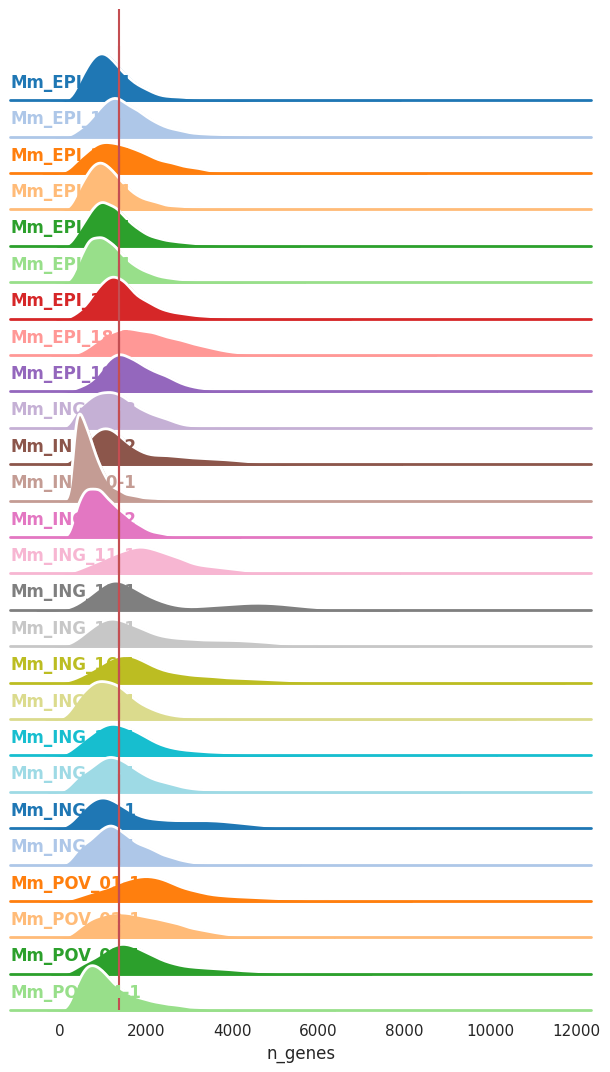

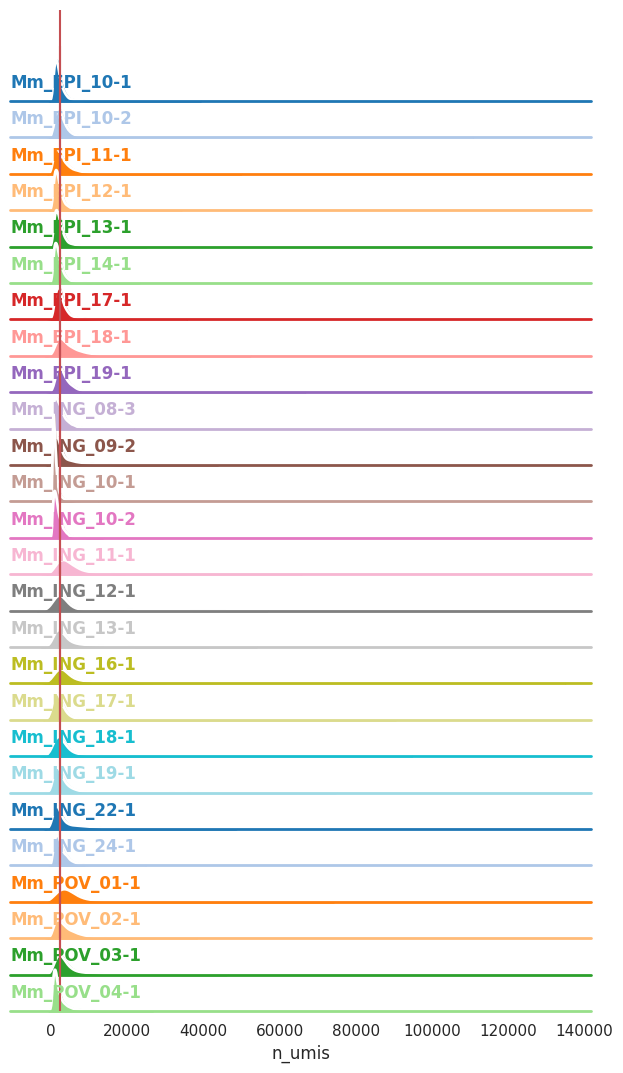

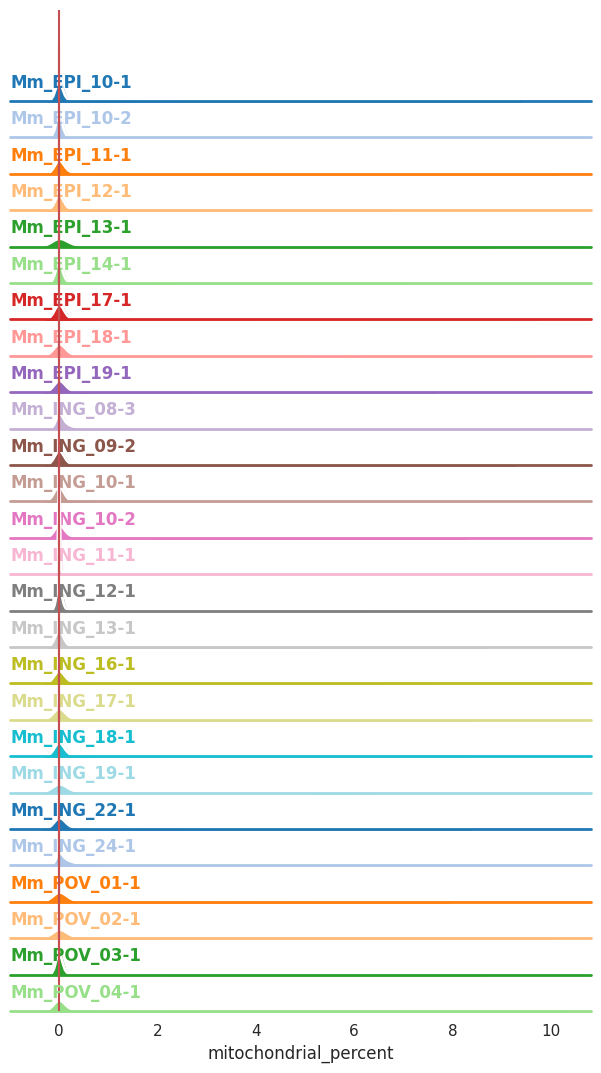

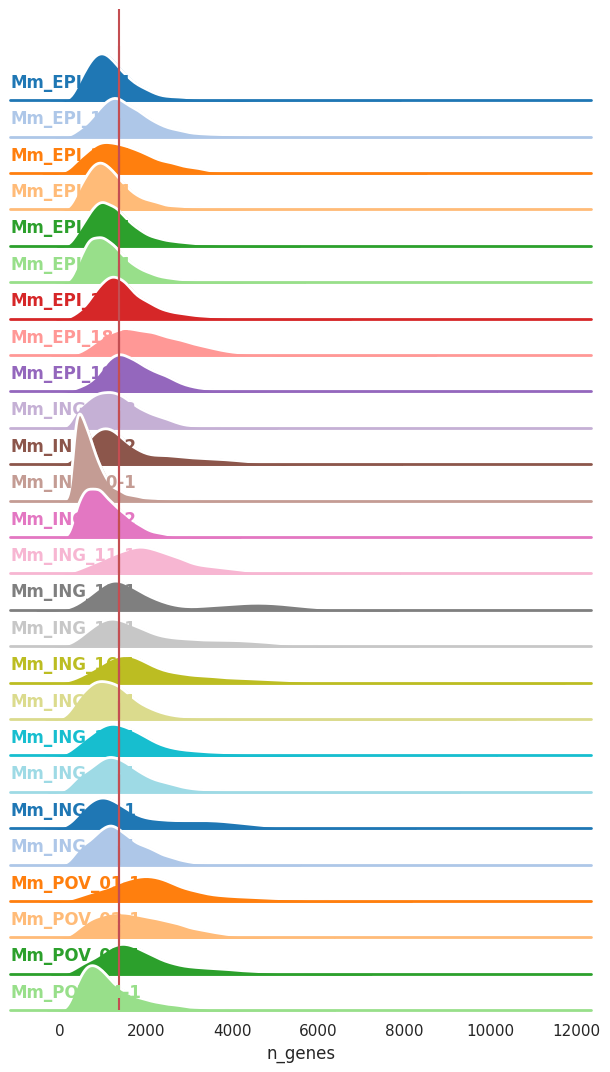

In [15]:
groupby = "biosample_id"

check_QCPlot(adata.obs, "n_umis", groupby)
check_QCPlot(adata.obs, "mitochondrial_percent", groupby)
check_QCPlot(adata.obs, "n_genes", groupby)

# Reload

In [ ]:
# load
annotation = "doublet_cleaned"
savedir = os.path.join(DATADIR, "processed", "single cell", study)
adata = sc.read_h5ad(os.path.join(savedir, f"{annotation}.h5ad"))